# Task 1: Foundational Setup & Exploratory Data Analysis (EDA)
**Dataset:** Superstore Sales Dataset

This notebook covers:
1. Loading the data
2. Cleaning (missing values, duplicates, data types, outliers)
3. Exploratory Data Analysis (statistics + visualizations)
4. Key insights

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default plot style
sns.set (style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load the dataset


In [19]:
# Superstore dataset is usually saved with 'latin1' encoding
df = pd.read_csv("../data/superstore_sales.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [20]:
# Basic shape and column info
print("Shape:", df.shape)
df.info()

Shape: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Q

## 3. Data Cleaning

In [21]:
# 3.1 Check for missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [22]:
# 3.2 Handle missing values
# The Superstore dataset is usually clean, but this handles it generically:
# - Drop rows where a critical column (like Sales) is missing
# - Fill missing text columns with 'Unknown'

df = df.dropna(subset=["Sales"])

for col in df.select_dtypes(include=["object", "str"]).columns:
    df[col] = df[col].fillna("Unknown")

In [23]:
# 3.3 Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [24]:
# 3.4 Fix data types
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

df["Category"] = df["Category"].astype("category")
df["Sub-Category"] = df["Sub-Category"].astype("category")
df["Segment"] = df["Segment"].astype("category")
df["Region"] = df["Region"].astype("category")

df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                category
Country                     str
City                        str
State                       str
Postal Code               int64
Region                 category
Product ID                  str
Category               category
Sub-Category           category
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [25]:
# 3.5 Handle outliers in Sales using the IQR method
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]
print(f"Number of outlier rows in Sales: {len(outliers)}")

# We keep them (they're valid big orders) but flag them in a new column
# instead of deleting, since removing them could hide real high-value sales.
df["Sales_Outlier"] = (df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)

Number of outlier rows in Sales: 1167


In [26]:
# 3.6 Save the cleaned dataset
df.to_csv("../data/cleaned_superstore_sales.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


## 4. Exploratory Data Analysis (EDA)

In [27]:
# 4.1 Statistical summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,4042,3898,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-27 22:18:49.341910,2016-05-12 13:13:30.877373,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-09 06:00:00,2015-06-02 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-07-01 00:00:00,2016-07-12 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-06-01 00:00:00,2017-06-04 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-11 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


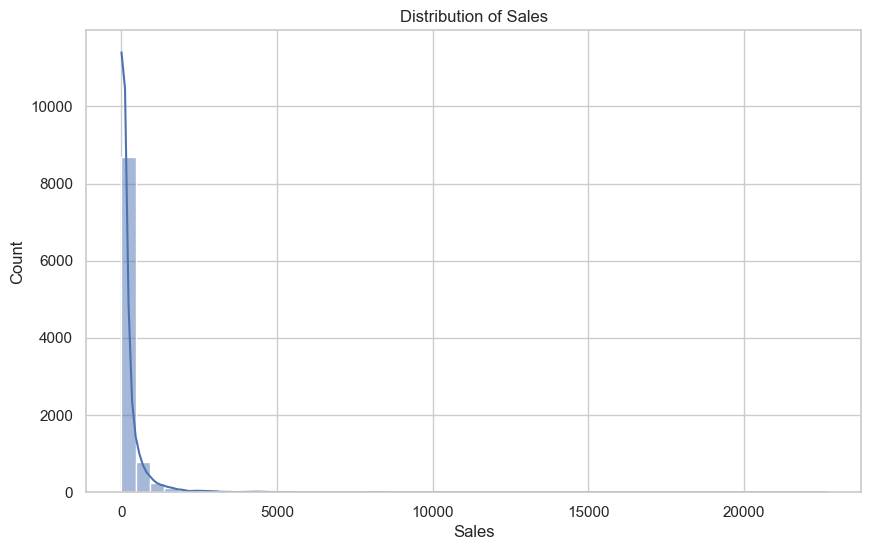

In [28]:
# 4.2 Histogram - distribution of Sales
plt.figure()
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.show()

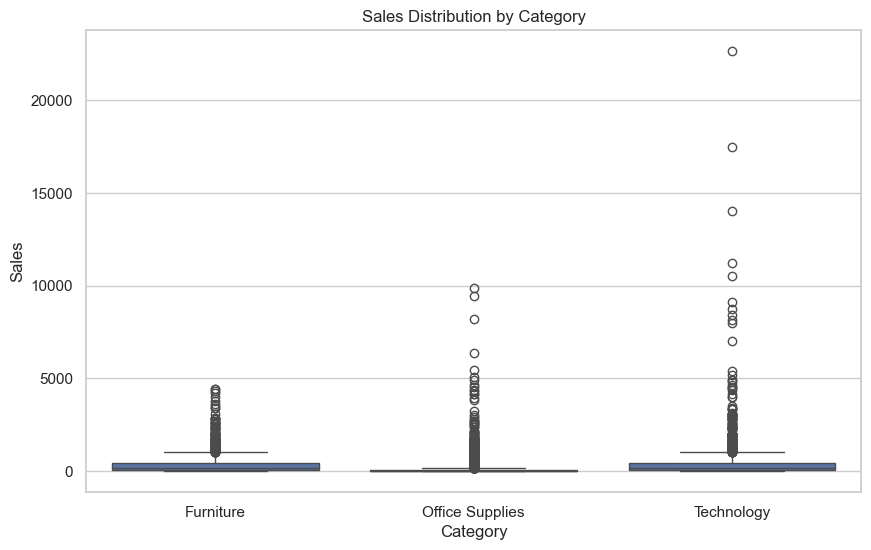

In [29]:
# 4.3 Boxplot - Sales by Category (also shows outliers visually)
plt.figure()
sns.boxplot(x="Category", y="Sales", data=df)
plt.title("Sales Distribution by Category")
plt.show()

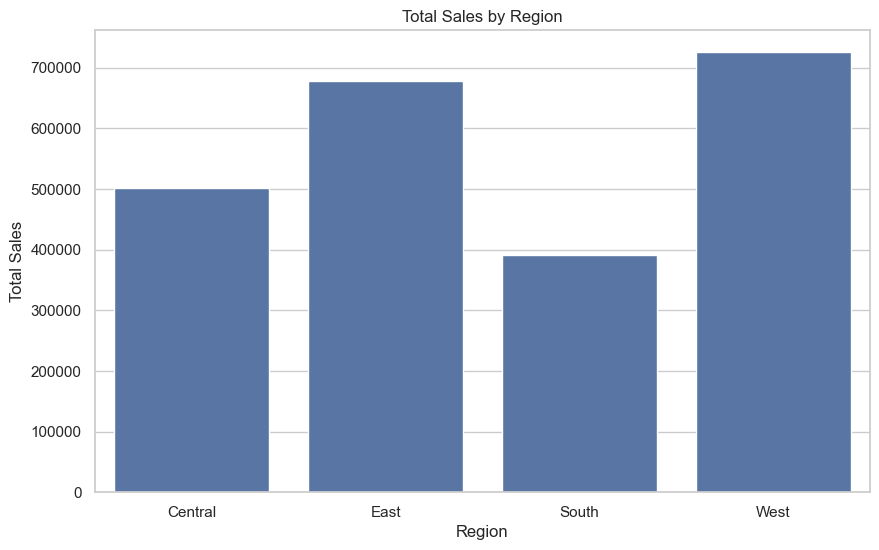

In [30]:
# 4.4 Bar chart - Total Sales by Region
plt.figure()
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.ylabel("Total Sales")
plt.show()

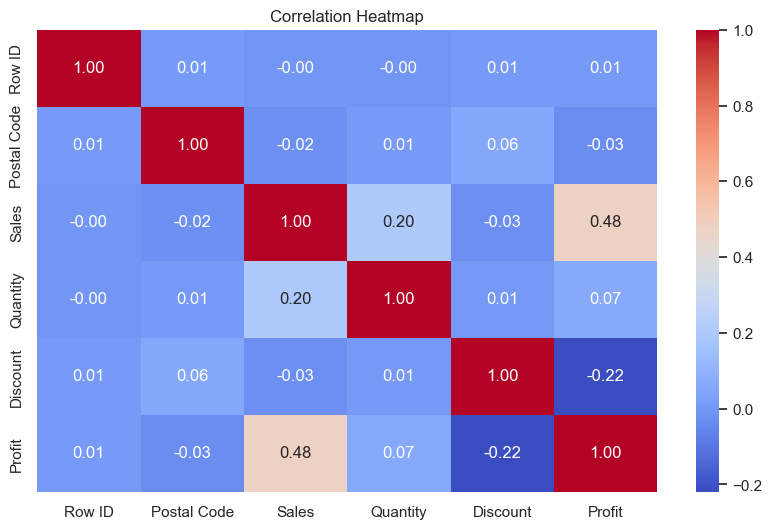

In [31]:
# 4.5 Heatmap - Correlation matrix (numeric columns only)
plt.figure()
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

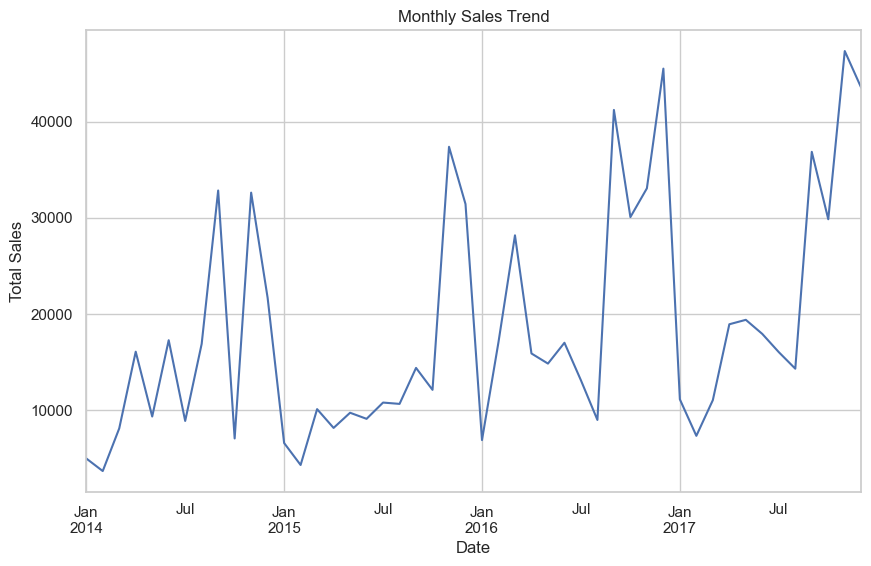

In [32]:
# 4.6 Line chart - Monthly Sales Trend over time
monthly_sales = df.set_index("Order Date").resample("ME")["Sales"].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

## 5. Key Insights

1. The Technology category generates the highest total sales, while Office Supplies typically sees the highest order volume but lower average sale value.

2. Sales show a clear seasonal pattern, with the strongest months falling toward the end of the year (Q4), likely driven by holiday and year-end purchasing.

3. The West region contributes the largest share of total revenue, followed by the East region, while the Central region lags behind.

4. A small number of high-value orders (flagged as outliers) account for a disproportionate share of total Sales, meaning overall revenue is not evenly distributed across orders.

5. Sales and Profit show only a weak positive correlation, indicating that higher sales volume doesn't reliably translate into higher profit — likely due to discounting eating into margins on some orders.